<a href="https://colab.research.google.com/github/yogitaalone04-web/machine-learning-practicals/blob/main/Artificial_Neural_Network_Heart_Failure_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

CS24D017: Yogita Alone

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

import tensorflow as tf

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
df = pd.read_csv("/content/drive/MyDrive/ML_Dataset/Heart_Failure_Prediction_dataset.csv")
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [5]:
df.isnull().sum()

,0
Age,0
Sex,0
ChestPainType,0
RestingBP,0
Cholesterol,0
FastingBS,0
RestingECG,0
MaxHR,0
ExerciseAngina,0
Oldpeak,0


In [6]:
df = df.dropna()

In [7]:
df = pd.get_dummies(df, drop_first=True)

In [8]:
X = df.drop("HeartDisease", axis=1)
y = df["HeartDisease"]

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [31]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [10]:
sc = StandardScaler()

X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [11]:
ann = tf.keras.models.Sequential()

# Input Layer
ann.add(tf.keras.Input(shape=(X_train.shape[1],)))

# Hidden Layer 1
ann.add(tf.keras.layers.Dense(units=16, activation='relu'))

# Hidden Layer 2
ann.add(tf.keras.layers.Dense(units=8, activation='relu'))

# Output Layer
ann.add(tf.keras.layers.Dense(units=1, activation='sigmoid'))

In [12]:
ann.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [13]:
history = ann.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.5975 - loss: 0.6329 - val_accuracy: 0.7551 - val_loss: 0.5808
Epoch 2/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7062 - loss: 0.5908 - val_accuracy: 0.8027 - val_loss: 0.5350
Epoch 3/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8413 - loss: 0.5225 - val_accuracy: 0.8231 - val_loss: 0.4925
Epoch 4/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8610 - loss: 0.4735 - val_accuracy: 0.8299 - val_loss: 0.4589
Epoch 5/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8414 - loss: 0.4562 - val_accuracy: 0.8299 - val_loss: 0.4346
Epoch 6/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8715 - loss: 0.4021 - val_accuracy: 0.8299 - val_loss: 0.4171
Epoch 7/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8672 - loss: 0.3993 - val_accuracy: 0.8231 - val_loss: 0.4084
Epoch 8/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8550 - loss: 0.3940 - val_accuracy: 0.8231 - val_loss

In [14]:
loss, accuracy = ann.evaluate(X_test, y_test)
print("Test Accuracy:", accuracy)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8364 - loss: 0.3557
Test Accuracy: 0.8478260636329651


In [15]:
y_pred = ann.predict(X_test)
y_pred = (y_pred > 0.5)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


In [16]:
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Confusion Matrix:
[[67 10]
 [18 89]]


In [17]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.87      0.83        77
           1       0.90      0.83      0.86       107

    accuracy                           0.85       184
   macro avg       0.84      0.85      0.85       184
weighted avg       0.85      0.85      0.85       184



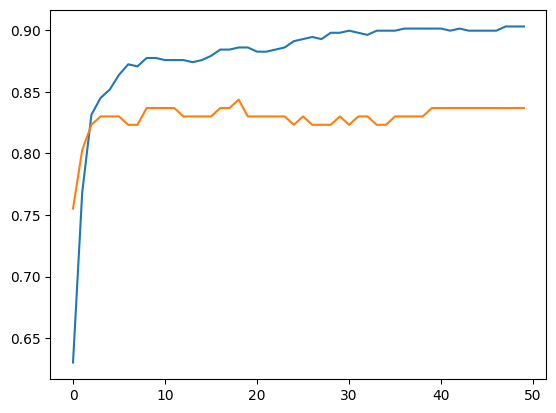

In [18]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

Text(0.5, 1.0, 'Model Accuracy')

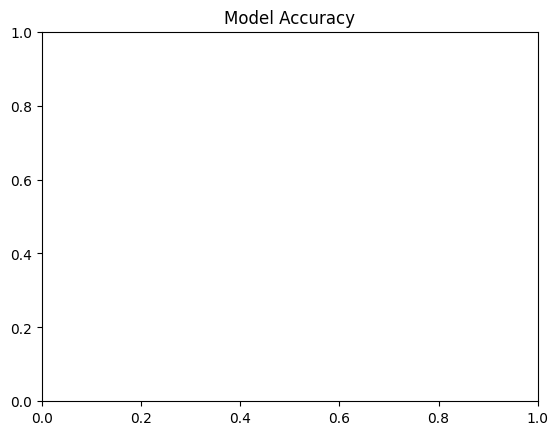

In [19]:
plt.title("Model Accuracy")

Text(0.5, 0, 'Epoch')

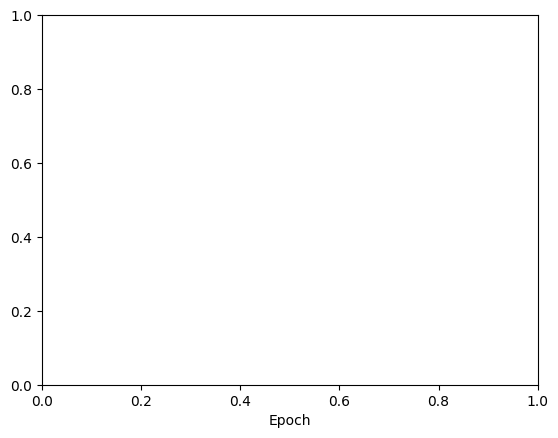

In [20]:
plt.xlabel("Epoch")

Text(0, 0.5, 'Accuracy')

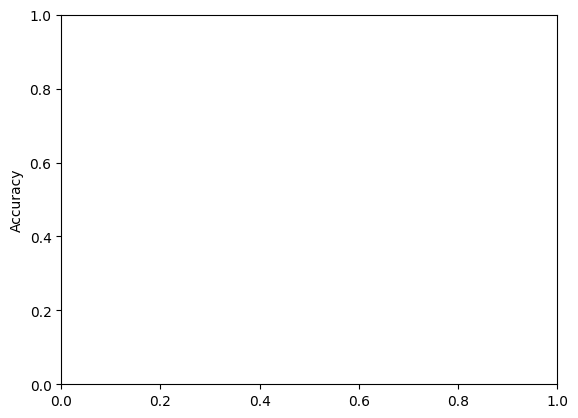

In [21]:
plt.ylabel("Accuracy")

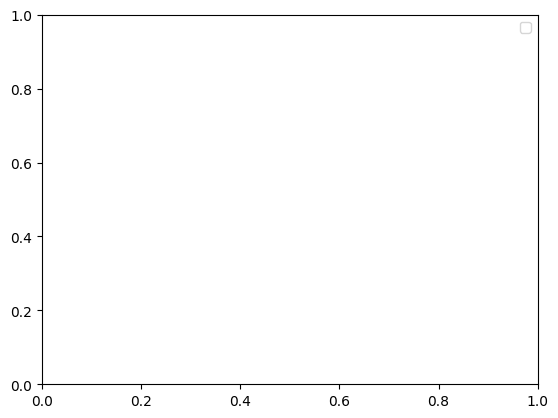

In [22]:
plt.legend(["Train", "Validation"])

In [23]:
loss, accuracy = ann.evaluate(X_test, y_test)
print("Final Test Accuracy:", accuracy)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8364 - loss: 0.3557
Final Test Accuracy: 0.8478260636329651


In [24]:
y_pred_prob = ann.predict(X_test)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


In [25]:
y_pred = (y_pred_prob > 0.5).astype(int)

In [26]:
from sklearn.metrics import accuracy_score

print("Accuracy Score:", accuracy_score(y_test, y_pred))

Accuracy Score: 0.8478260869565217


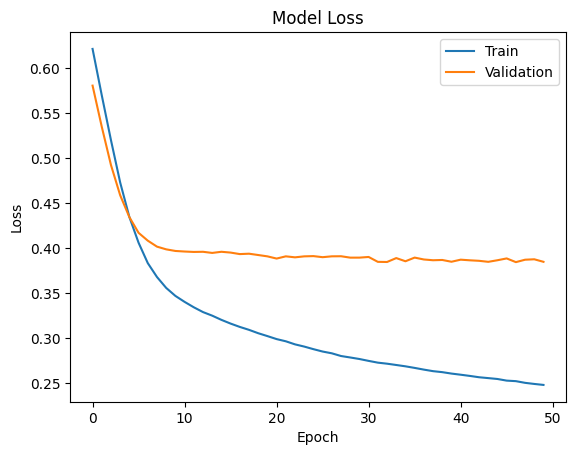

In [28]:
# Loss Graph
plt.figure()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train", "Validation"])
plt.show()